In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split,cross_val_score,GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
from sklearn.metrics import accuracy_score
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso

In [3]:
df=pd.read_csv('All_Companyreport.csv')

In [4]:
df.head()

,S.No,Name,Current Market price(Rs),Price to Earning,Market Capitilization,Dividend yield,Net Profit latest quarter,YOY Quarterly profit Growth,Sales latest quarter,YOY Quarter sales growth,Return on capital employed
0,1,Reliance Industries,1441.3,25.43,1951385.25,0.38,22290.00,0.57,264905.00,10.38,9.69
1,2,HDFC Bank,924.7,19.10,1423474.37,1.19,20691.04,12.18,87066.94,2.38,7.51
2,3,Bharti Airtel,2021.8,37.63,1152851.65,0.79,8502.80,-18.76,53981.60,19.62,13.48
3,4,SBI,1218.9,13.88,1125306.27,1.30,22175.72,13.07,130589.72,4.76,6.47
4,5,ICICI Bank,1408.2,19.05,1008710.67,0.78,13481.13,-2.68,48363.84,2.82,7.87


In [5]:
df.tail()

,S.No,Name,Current Market price(Rs),Price to Earning,Market Capitilization,Dividend yield,Net Profit latest quarter,YOY Quarterly profit Growth,Sales latest quarter,YOY Quarter sales growth,Return on capital employed
3825,5275,Brilliant Port.,8.46,4.68,2.62,0.0,0.11,-8.33,0.70,-5.41,9.18
3826,5281,Mudra Fin Ser,4.30,NaN,2.15,0.0,-0.02,-112.50,0.26,18.18,3.16
3827,5283,Baron Infotech,1.58,NaN,1.61,0.0,-0.09,83.02,0.00,-100.00,-7.55
3828,5286,Silveroak Comm,5.08,NaN,1.40,0.0,-0.14,84.62,0.00,-100.00,-77.32
3829,5287,India Radiators,13.72,NaN,1.23,0.0,-0.19,-26.67,0.02,0.00,-454.55


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3830 entries, 0 to 3829
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   S.No                         3830 non-null   int64  
 1   Name                         3830 non-null   object 
 2   Current Market price(Rs)     3830 non-null   float64
 3   Price to Earning             3751 non-null   float64
 4   Market Capitilization        3830 non-null   float64
 5   Dividend yield               3830 non-null   float64
 6   Net Profit latest quarter    3830 non-null   float64
 7   YOY Quarterly profit Growth  3828 non-null   float64
 8   Sales latest quarter         3830 non-null   float64
 9   YOY Quarter sales growth     3802 non-null   float64
 10  Return on capital employed   3823 non-null   float64
dtypes: float64(9), int64(1), object(1)
memory usage: 329.3+ KB


In [7]:
df.shape

(3830, 11)

In [8]:
df.sample(5)

,S.No,Name,Current Market price(Rs),Price to Earning,Market Capitilization,Dividend yield,Net Profit latest quarter,YOY Quarterly profit Growth,Sales latest quarter,YOY Quarter sales growth,Return on capital employed
3397,4362,Vrundavan Planta,38.00,13.07,23.52,0.0,1.25,3.31,16.40,26.45,10.38
3257,4103,STL Global,11.95,323.03,32.30,0.0,0.31,158.33,29.75,-15.17,1.08
309,323,Tenneco Clean,553.65,39.52,22327.22,0.0,118.81,10.26,1285.26,14.23,57.30
2709,3264,Retina Paints,57.50,76.70,88.21,0.0,0.20,-42.86,8.00,37.22,8.06
1292,1440,Finkurve Fin.,79.99,50.52,1106.40,0.0,6.98,23.76,51.96,30.32,11.40


In [9]:
df.isnull().sum()

S.No                            0
Name                            0
Current Market price(Rs)        0
Price to Earning               79
Market Capitilization           0
Dividend yield                  0
Net Profit latest quarter       0
YOY Quarterly profit Growth     2
Sales latest quarter            0
YOY Quarter sales growth       28
Return on capital employed      7
dtype: int64

In [10]:
df['Name'].value_counts()

Name
India Radiators        1
Reliance Industries    1
HDFC Bank              1
Bharti Airtel          1
SBI                    1
                      ..
Hind. Unilever         1
Life Insurance         1
Infosys                1
Larsen & Toubro        1
Bajaj Finance          1
Name: count, Length: 3830, dtype: int64

In [11]:
df.drop('S.No',axis=1,inplace=True)

In [12]:
df['Price to Earning']=df['Price to Earning'].fillna(df['Price to Earning'].mean())

In [13]:
df['Current Market price(Rs)']=df['Current Market price(Rs)'].fillna(df['Current Market price(Rs)'].median())

In [14]:
df['Dividend yield']=df['Dividend yield'].fillna(df['Dividend yield'].median())

In [15]:
df['Net Profit latest quarter']=df['Net Profit latest quarter'].fillna(df['Net Profit latest quarter'].median())

In [16]:
df['Sales latest quarter']=df['Sales latest quarter'].fillna(df['Sales latest quarter'].median())

In [17]:
df['YOY Quarterly profit Growth']=df['YOY Quarterly profit Growth'].fillna(df['YOY Quarterly profit Growth'].mean())

In [18]:
df['YOY Quarter sales growth']=df['YOY Quarter sales growth'].fillna(df['YOY Quarter sales growth'].mean())

In [19]:
df['Return on capital employed']=df['Return on capital employed'].fillna(df['Return on capital employed'].mean())

In [20]:
df.isnull().sum()

Name                           0
Current Market price(Rs)       0
Price to Earning               0
Market Capitilization          0
Dividend yield                 0
Net Profit latest quarter      0
YOY Quarterly profit Growth    0
Sales latest quarter           0
YOY Quarter sales growth       0
Return on capital employed     0
dtype: int64

In [21]:
numeric_cols=df.select_dtypes(include="number").columns

In [22]:
numeric_cols

Index(['Current Market price(Rs)', 'Price to Earning', 'Market Capitilization',
       'Dividend yield', 'Net Profit latest quarter',
       'YOY Quarterly profit Growth', 'Sales latest quarter',
       'YOY Quarter sales growth', 'Return on capital employed'],
      dtype='object')

In [23]:
columns=['Current Market price(Rs)', 'Price to Earning',
       'Market Capitilization', 'Dividend yield', 'Net Profit latest quarter',
       'YOY Quarterly profit Growth', 'Sales latest quarter',
       'YOY Quarter sales growth', 'Return on capital employed']

In [24]:
for col in columns:
    q1=df[col].quantile(0.25)
    q3=df[col].quantile(0.75)
    iqr=q3-q1
    lower_bound=q1-1.5*iqr
    upper_bound=q3+1.5*iqr
    outliers=df[(df[col]<lower_bound) | (df[col]>upper_bound)]
    print(outliers.shape)

(459, 10)
(328, 10)
(665, 10)
(461, 10)
(642, 10)
(490, 10)
(565, 10)
(588, 10)
(215, 10)


In [25]:
for col in columns:
    q1=df[col].quantile(0.25)
    q3=df[col].quantile(0.75)
    iqr=q3-q1
    lower_bound=q1-1.5*iqr
    upper_bound=q3+1.5*iqr
    df[col]=df[col].clip(lower=lower_bound,upper=upper_bound)
    outliers=df[(df[col]<lower_bound) | (df[col]>upper_bound)]
    print(outliers.shape)

(0, 10)
(0, 10)
(0, 10)
(0, 10)
(0, 10)
(0, 10)
(0, 10)
(0, 10)
(0, 10)


In [26]:
import category_encoders as ce

In [27]:
encoder = ce.OrdinalEncoder(['Name'])

In [28]:
df1=encoder.fit_transform(df)

In [29]:
df1.head()

,Name,Current Market price(Rs),Price to Earning,Market Capitilization,Dividend yield,Net Profit latest quarter,YOY Quarterly profit Growth,Sales latest quarter,YOY Quarter sales growth,Return on capital employed
0,1,962.6125,25.43,6238.29875,0.380,60.575,0.57,885.82,10.38,9.69
1,2,924.7000,19.10,6238.29875,1.190,60.575,12.18,885.82,2.38,7.51
2,3,962.6125,37.63,6238.29875,0.790,60.575,-18.76,885.82,19.62,13.48
3,4,962.6125,13.88,6238.29875,1.225,60.575,13.07,885.82,4.76,6.47
4,5,962.6125,19.05,6238.29875,0.780,60.575,-2.68,885.82,2.82,7.87


In [30]:
df1.corr()

,Name,Current Market price(Rs),Price to Earning,Market Capitilization,Dividend yield,Net Profit latest quarter,YOY Quarterly profit Growth,Sales latest quarter,YOY Quarter sales growth,Return on capital employed
Name,1.000000,-0.666610,-0.086173,-0.841192,-0.379369,-0.756203,0.006137,-0.771168,-0.030945,-0.287989
Current Market price(Rs),-0.666610,1.000000,0.137963,0.641307,0.267900,0.564635,0.012388,0.528441,0.058139,0.267515
Price to Earning,-0.086173,0.137963,1.000000,0.135071,-0.183680,-0.062512,-0.075432,0.004444,-0.006733,-0.262237
Market Capitilization,-0.841192,0.641307,0.135071,1.000000,0.346684,0.855564,-0.034662,0.852798,0.002154,0.202220
Dividend yield,-0.379369,0.267900,-0.183680,0.346684,1.000000,0.366238,-0.095931,0.365595,-0.122267,0.130773
Net Profit latest quarter,-0.756203,0.564635,-0.062512,0.855564,0.366238,1.000000,0.070324,0.800158,0.049581,0.249705
YOY Quarterly profit Growth,0.006137,0.012388,-0.075432,-0.034662,-0.095931,0.070324,1.000000,-0.024576,0.397913,-0.115443
Sales latest quarter,-0.771168,0.528441,0.004444,0.852798,0.365595,0.800158,-0.024576,1.000000,0.003284,0.152571
YOY Quarter sales growth,-0.030945,0.058139,-0.006733,0.002154,-0.122267,0.049581,0.397913,0.003284,1.000000,0.053294
Return on capital employed,-0.287989,0.267515,-0.262237,0.202220,0.130773,0.249705,-0.115443,0.152571,0.053294,1.000000


<Axes: >

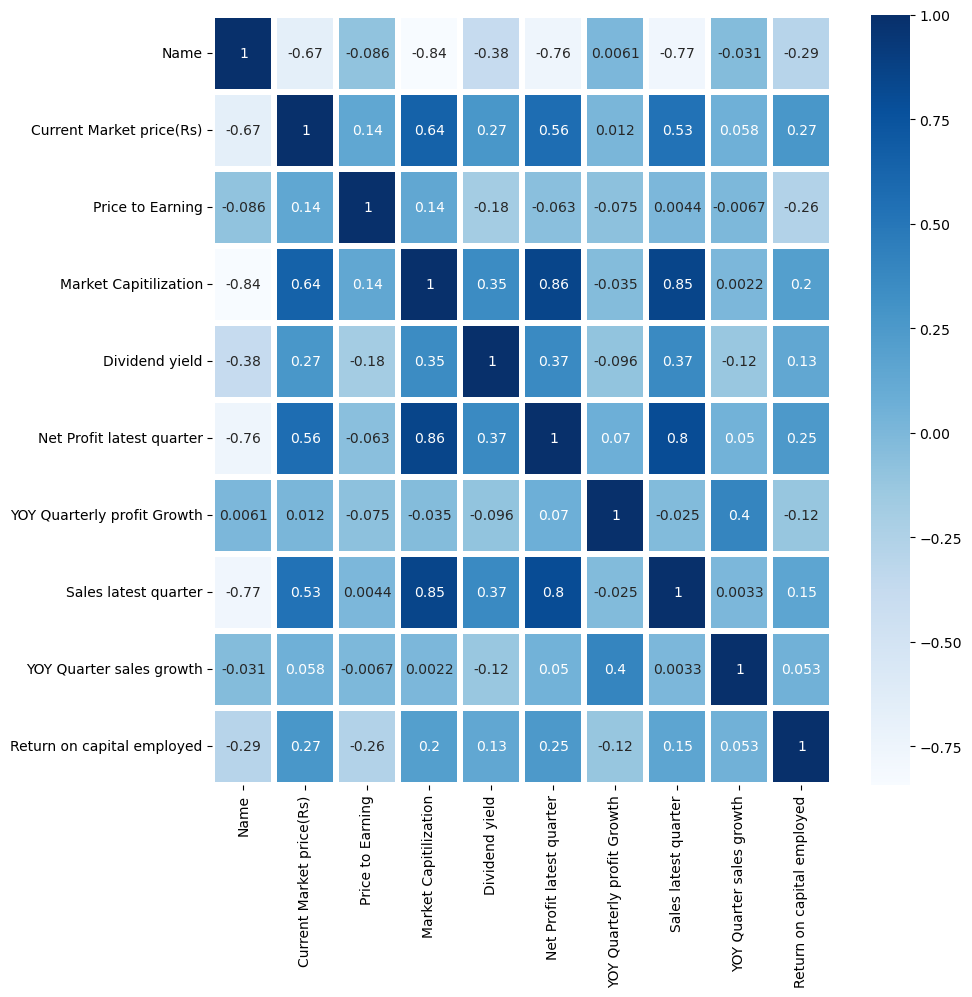

In [31]:
fig,ax=plt.subplots(figsize=(10,10))
sns.heatmap(df1.corr(),annot=True,ax=ax,linewidths=4,cmap="Blues")

In [32]:
X=df.drop('Return on capital employed',axis=1)
y=df['Return on capital employed']

In [33]:
scaler= StandardScaler()

In [34]:
X=pd.DataFrame(scaler.fit_transform(df1),columns=df1.columns)

In [35]:
X

,Name,Current Market price(Rs),Price to Earning,Market Capitilization,Dividend yield,Net Profit latest quarter,YOY Quarterly profit Growth,Sales latest quarter,YOY Quarter sales growth,Return on capital employed
0,-1.731599,2.111462,-0.306246,1.925042,0.211372,1.940171,-0.382928,2.020804,-0.210199,-0.430835
1,-1.730694,1.994279,-0.543749,1.925042,2.043682,1.940171,-0.275218,2.020804,-0.431888,-0.622461
2,-1.729790,2.111462,0.151502,1.925042,1.138838,1.940171,-0.562258,2.020804,0.045851,-0.097689
3,-1.728885,2.111462,-0.739605,1.925042,2.122856,1.940171,-0.266961,2.020804,-0.365935,-0.713878
4,-1.727981,2.111462,-0.545625,1.925042,1.116216,1.940171,-0.413079,2.020804,-0.419695,-0.590816
...,...,...,...,...,...,...,...,...,...,...
3825,1.727981,-0.837709,-1.084792,-0.714095,-0.648231,-0.694278,-0.465496,-0.766600,-0.647757,-0.475665
3826,1.728885,-0.850567,1.289395,-0.714294,-0.648231,-0.699942,-1.431914,-0.767985,0.005948,-1.004832
3827,1.729790,-0.858974,1.289395,-0.714523,-0.648231,-0.702992,0.381987,-0.768804,-2.028844,-1.946257
3828,1.730694,-0.848156,1.289395,-0.714612,-0.648231,-0.705171,0.396831,-0.768804,-2.028844,-2.503992


In [36]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2)

In [37]:
X_train

,Name,Current Market price(Rs),Price to Earning,Market Capitilization,Dividend yield,Net Profit latest quarter,YOY Quarterly profit Growth,Sales latest quarter,YOY Quarter sales growth,Return on capital employed
152,-1.594120,2.111462,-0.253717,1.925042,-0.467262,1.940171,1.180115,2.020804,1.925253,2.082267
665,-1.130129,0.083651,-0.454826,1.924848,2.122856,1.606644,-0.545002,0.364618,-0.549937,0.366431
2643,0.658903,-0.641005,-0.284859,-0.673499,0.912626,-0.642430,-0.327357,-0.618494,-0.262850,-0.769256
3270,1.226003,-0.661096,-1.018381,-0.702021,-0.648231,-0.596246,2.031459,-0.492306,1.925253,2.349927
1727,-0.169587,0.357967,2.260707,-0.529499,-0.648231,-0.691228,2.031459,-0.751358,1.925253,-1.010106
...,...,...,...,...,...,...,...,...,...,...
1297,-0.558507,2.111462,-0.659687,-0.255913,-0.648231,0.169711,0.340146,-0.446548,1.925253,0.433236
2119,0.184963,0.909998,-0.439818,-0.622178,2.122856,-0.621952,-0.759308,-0.567540,0.005948,-0.806175
3204,1.166308,-0.857738,-0.414679,-0.699845,-0.648231,-0.689050,-1.019630,-0.748744,-0.267007,-0.672565
2989,0.971848,-0.856625,-0.458203,-0.691592,-0.648231,-0.691228,-0.123163,-0.655875,-0.066378,-0.662016


In [38]:
y_train

152     38.280
665     18.760
2643     5.840
3270    41.325
1727     3.100
         ...  
1297    19.520
2119     5.420
3204     6.940
2989     7.060
1021    18.010
Name: Return on capital employed, Length: 3064, dtype: float64

In [39]:
X_test

,Name,Current Market price(Rs),Price to Earning,Market Capitilization,Dividend yield,Net Profit latest quarter,YOY Quarterly profit Growth,Sales latest quarter,YOY Quarter sales growth,Return on capital employed
3019,0.998982,-0.841851,-0.965853,-0.692959,-0.648231,-0.694278,0.617445,-0.758380,1.609866,-1.715076
3433,1.373430,-0.786678,2.260707,-0.706156,-0.648231,-0.708656,0.114336,-0.754224,-0.442972,-0.970550
345,-1.419558,2.011742,0.611501,1.925042,-0.173187,1.940171,-0.347025,0.363736,-0.520286,0.789237
1393,-0.471679,0.023225,0.047946,-0.332480,-0.648231,-0.682950,0.579872,0.319994,0.137021,-1.399510
2325,0.371283,-0.490170,-0.589149,-0.647745,1.229322,-0.543527,0.149497,-0.646994,0.784907,0.685513
...,...,...,...,...,...,...,...,...,...,...
197,-1.553419,2.111462,-0.305870,1.925042,2.122856,1.940171,-0.301195,2.020804,-0.154500,0.713642
1175,-0.668852,-0.838142,1.357780,-0.101247,-0.648231,-0.414996,-0.899025,0.272882,-0.825663,-0.319201
124,-1.619445,2.111462,-0.341515,1.925042,-0.489883,1.940171,1.078157,2.020804,1.925253,1.788676
857,-0.956472,0.671846,-0.514108,0.698475,-0.648231,1.940171,2.031459,0.445583,0.103213,-0.747281


In [40]:
y_test

3019    -4.92
3433     3.55
345     23.57
1393    -1.33
2325    22.39
        ...  
197     22.71
1175    10.96
124     34.94
857      6.09
2466    10.05
Name: Return on capital employed, Length: 766, dtype: float64

### Linear Regression model

In [41]:
model=LinearRegression()

In [42]:
model.fit(X_train,y_train)

LinearRegression()

### Mean Square Error

In [43]:
mse = cross_val_score(model,X_train,y_train,scoring='neg_mean_squared_error',cv=10)

In [44]:
mse

array([-2.88371836e-28, -3.21807200e-28, -9.46160782e-29, -1.66739456e-27,
       -1.41124302e-28, -4.64934302e-28, -5.78730947e-29, -5.16188650e-28,
       -4.41162791e-27, -7.99730860e-29])

In [45]:
mse.mean()

np.float64(-8.043911024956672e-28)

In [46]:
print(f'coeff.,{model.coef_}')
print(f'intercept,{model.intercept_}')

coeff.,[-3.77884078e-15 -2.05088064e-15  4.85575718e-15 -5.67412063e-15
  6.17677203e-16  5.98545423e-15 -1.98862231e-15 -1.07400445e-15
 -6.36857474e-16  1.13763748e+01]
intercept,14.591345933196695


In [47]:
X_train.columns

Index(['Name', 'Current Market price(Rs)', 'Price to Earning',
       'Market Capitilization', 'Dividend yield', 'Net Profit latest quarter',
       'YOY Quarterly profit Growth', 'Sales latest quarter',
       'YOY Quarter sales growth', 'Return on capital employed'],
      dtype='object')

In [48]:
list(zip(X_train.columns,model.coef_))

[('Name', np.float64(-3.778840781483258e-15)),
 ('Current Market price(Rs)', np.float64(-2.0508806406329246e-15)),
 ('Price to Earning', np.float64(4.855757183314856e-15)),
 ('Market Capitilization', np.float64(-5.674120628875983e-15)),
 ('Dividend yield', np.float64(6.17677203485031e-16)),
 ('Net Profit latest quarter', np.float64(5.985454228078508e-15)),
 ('YOY Quarterly profit Growth', np.float64(-1.988622312780736e-15)),
 ('Sales latest quarter', np.float64(-1.0740044463316273e-15)),
 ('YOY Quarter sales growth', np.float64(-6.368574736329023e-16)),
 ('Return on capital employed', np.float64(11.376374807048931))]

In [49]:
y_pred=model.predict(X_test)
x_pred=model.predict(X_train)

In [50]:
y_pred[0:10]

array([-4.92,  3.55, 23.57, -1.33, 22.39, 11.92, 17.84, 22.22,  6.48,
       22.97])

In [51]:
x_pred[0:10]

array([38.28 , 18.76 ,  5.84 , 41.325,  3.1  , 12.62 , 10.59 ,  8.75 ,
        6.53 , 16.21 ])

In [52]:
mse = mean_squared_error(y_test,y_pred)

In [53]:
mse

3.953193161473835e-29

In [54]:
mae = mean_absolute_error(y_test,y_pred)

In [55]:
mae

4.764861898573553e-15

In [56]:
rmse = np.sqrt(mean_squared_error(y_test,y_pred))

In [57]:
rmse

np.float64(6.287442374665421e-15)

In [58]:
r2 = r2_score(y_test,y_pred)

In [59]:
r2

1.0

In [60]:
n = len(y_test)
p = X_test.shape[1]

adj_r2 = 1-((1-r2)*(n-1)/(n-p-1))

In [61]:
adj_r2

1.0

In [62]:
reg_df=pd.DataFrame({'Actual':y_test,'Prediction':y_pred,'Diff %':((y_test - y_pred) / y_test)*100})

In [63]:
reg_df

,Actual,Prediction,Diff %
3019,-4.92,-4.92,-1.083144e-13
3433,3.55,3.55,-2.752102e-13
345,23.57,23.57,-1.507303e-14
1393,-1.33,-1.33,-1.335607e-13
2325,22.39,22.39,1.586741e-14
...,...,...,...
197,22.71,22.71,0.000000e+00
1175,10.96,10.96,-9.724581e-14
124,34.94,34.94,4.067217e-14
857,6.09,6.09,-5.833684e-14


In [64]:
print(model.score(X_train,y_train))
print(model.score(X_test,y_test))

1.0
1.0


In [65]:
ridge = Ridge(alpha = 1.0)
ridge.fit(X_train,y_train)
ridge.coef_

array([-1.74306516e-03,  9.39949320e-04, -1.57512359e-03, -2.72583040e-04,
       -2.70368342e-04,  7.72058927e-04, -9.78224185e-04, -1.42035128e-03,
        4.47530794e-04,  1.13714702e+01])

In [66]:
model.coef_

array([-3.77884078e-15, -2.05088064e-15,  4.85575718e-15, -5.67412063e-15,
        6.17677203e-16,  5.98545423e-15, -1.98862231e-15, -1.07400445e-15,
       -6.36857474e-16,  1.13763748e+01])

In [67]:
print(ridge.score(X_train,y_train))
print(ridge.score(X_train,y_train))

0.9999998591491062
0.9999998591491062


In [68]:
lasso = Lasso(alpha = 1.0)
lasso.fit(X_train,y_train)
lasso.coef_

array([-0.        ,  0.        , -0.        ,  0.        ,  0.        ,
        0.        , -0.        ,  0.        ,  0.        , 10.37473479])

In [69]:
print(lasso.score(X_train,y_train))
print(lasso.score(X_train,y_train))

0.9922479680530205
0.9922479680530205


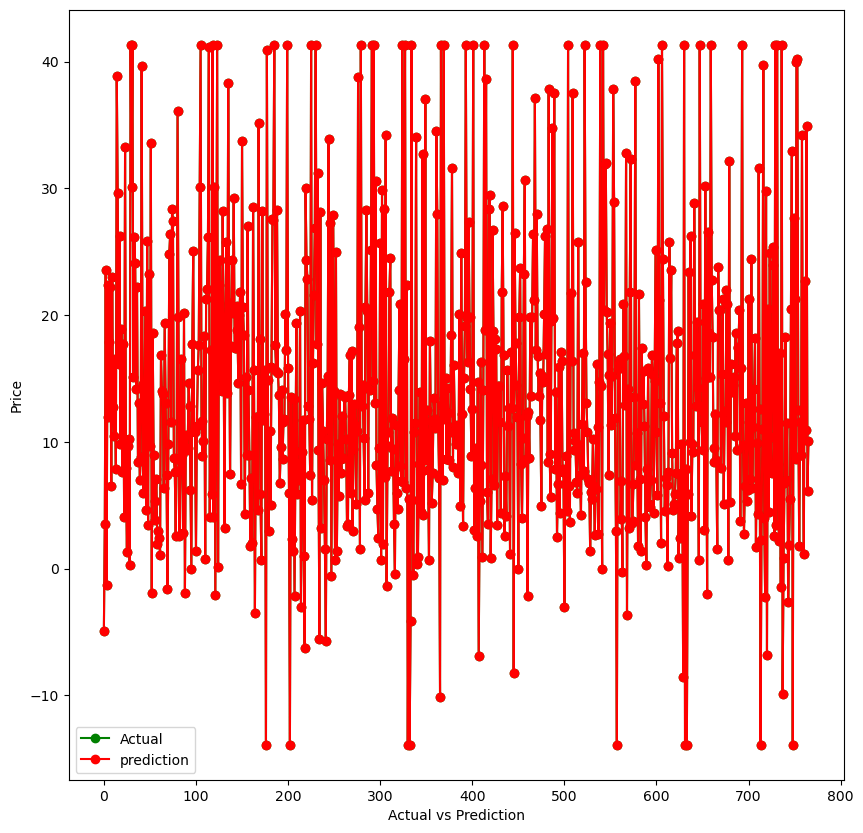

In [70]:
plt.figure(figsize=(10,10))
plt.plot(
    reg_df['Actual'].values,
    color = 'Green',
    marker = 'o',
    label ='Actual')

plt.plot(
    reg_df['Prediction'].values,
    color = 'Red',
    marker = 'o',
    label ='prediction')
    
plt.xlabel('Actual vs Prediction')
plt.ylabel('Price')
plt.legend()
plt.show()

### Decision Tree

In [71]:
from sklearn.tree import DecisionTreeRegressor

In [72]:
DT = DecisionTreeRegressor(criterion='squared_error',random_state=42,max_depth=7)

In [73]:
DT.fit(X_train,y_train)

DecisionTreeRegressor(max_depth=7, random_state=42)

In [74]:
y_pred = DT.predict(X_test)

In [75]:
y_pred[0:10]

array([-4.8425    ,  3.35241379, 23.74875   , -0.934     , 22.35043478,
       11.80288462, 17.92346154, 22.35043478,  6.61534247, 22.99315789])

In [76]:
dt_mse = mean_squared_error(y_test,y_pred)

In [77]:
dt_mse

0.019277469139762082

In [78]:
dt_mae = mean_absolute_error(y_test,y_pred)

In [79]:
dt_mae

0.10457205526164778

In [80]:
dt_rmse = np.sqrt(mean_squared_error(y_test,y_pred))

In [81]:
dt_rmse

np.float64(0.13884332587402998)

In [82]:
dt_r2 = r2_score(y_test,y_pred)

In [83]:
dt_r2

0.9998517033918632

In [84]:
n = len(y_test)
p = X_test.shape[1]

dt_adj_r2 = 1-((1-r2)*(n-1)/(n-p-1))

In [85]:
dt_adj_r2

1.0

In [86]:
dtmodel=pd.DataFrame({'Actual':y_test,'Prediction':y_pred,'Diff %':((y_test - y_pred) / y_test)*100})

In [87]:
dtmodel

,Actual,Prediction,Diff %
3019,-4.92,-4.842500,1.575203
3433,3.55,3.352414,5.565809
345,23.57,23.748750,-0.758379
1393,-1.33,-0.934000,29.774436
2325,22.39,22.350435,0.176709
...,...,...,...
197,22.71,22.682222,0.122315
1175,10.96,10.836667,1.125304
124,34.94,34.718889,0.632831
857,6.09,6.068276,0.356718


In [88]:
ridge = Ridge(alpha = 1.0)
ridge.fit(X_train,y_train)
ridge.coef_

array([-1.74306516e-03,  9.39949320e-04, -1.57512359e-03, -2.72583040e-04,
       -2.70368342e-04,  7.72058927e-04, -9.78224185e-04, -1.42035128e-03,
        4.47530794e-04,  1.13714702e+01])

In [89]:
print(ridge.score(X_train,y_train))
print(ridge.score(X_train,y_train))

0.9999998591491062
0.9999998591491062


In [90]:
lasso = Lasso(alpha = 1.0)
lasso.fit(X_train,y_train)
lasso.coef_

array([-0.        ,  0.        , -0.        ,  0.        ,  0.        ,
        0.        , -0.        ,  0.        ,  0.        , 10.37473479])

In [91]:
print(lasso.score(X_train,y_train))
print(lasso.score(X_train,y_train))

0.9922479680530205
0.9922479680530205


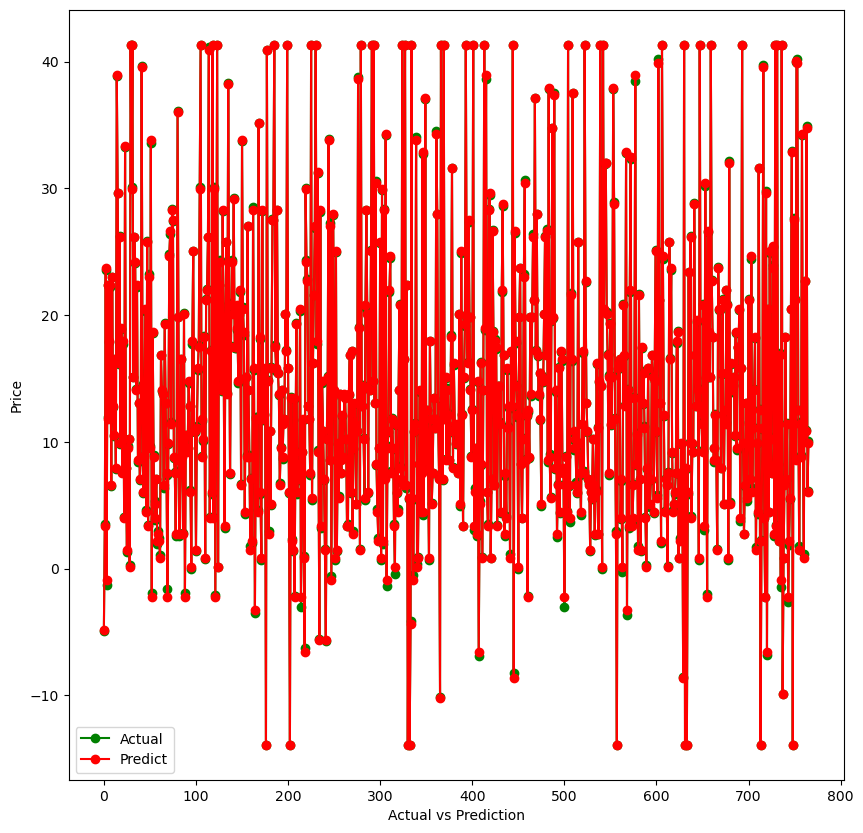

In [92]:
plt.figure(figsize=(10,10))
plt.plot(
    dtmodel['Actual'].values,
    color = 'Green',
    marker = 'o',
    label ='Actual')

plt.plot(
    dtmodel['Prediction'].values,
    color = 'Red',
    marker = 'o',
    label ='Predict')
    
plt.xlabel('Actual vs Prediction')
plt.ylabel('Price')
plt.legend()
plt.show()

### Decision Tree

[Text(0.5, 0.9375, 'x[9] <= 0.336\nsquared_error = 129.21\nsamples = 3064\nvalue = 14.709'),
 Text(0.25, 0.8125, 'x[9] <= -0.599\nsquared_error = 37.791\nsamples = 2106\nvalue = 8.519'),
 Text(0.375, 0.875, 'True  '),
 Text(0.125, 0.6875, 'x[9] <= -1.557\nsquared_error = 22.326\nsamples = 894\nvalue = 2.901'),
 Text(0.0625, 0.5625, 'x[9] <= -2.103\nsquared_error = 14.237\nsamples = 72\nvalue = -10.117'),
 Text(0.03125, 0.4375, 'x[9] <= -2.36\nsquared_error = 2.282\nsamples = 44\nvalue = -12.874'),
 Text(0.015625, 0.3125, 'x[9] <= -2.462\nsquared_error = 0.093\nsamples = 32\nvalue = -13.765'),
 Text(0.0078125, 0.1875, 'x[9] <= -2.494\nsquared_error = 0.007\nsamples = 28\nvalue = -13.873'),
 Text(0.00390625, 0.0625, 'squared_error = 0.0\nsamples = 26\nvalue = -13.895'),
 Text(0.01171875, 0.0625, 'squared_error = 0.006\nsamples = 2\nvalue = -13.585'),
 Text(0.0234375, 0.1875, 'x[1] <= -0.805\nsquared_error = 0.038\nsamples = 4\nvalue = -13.008'),
 Text(0.01953125, 0.0625, 'squared_error =

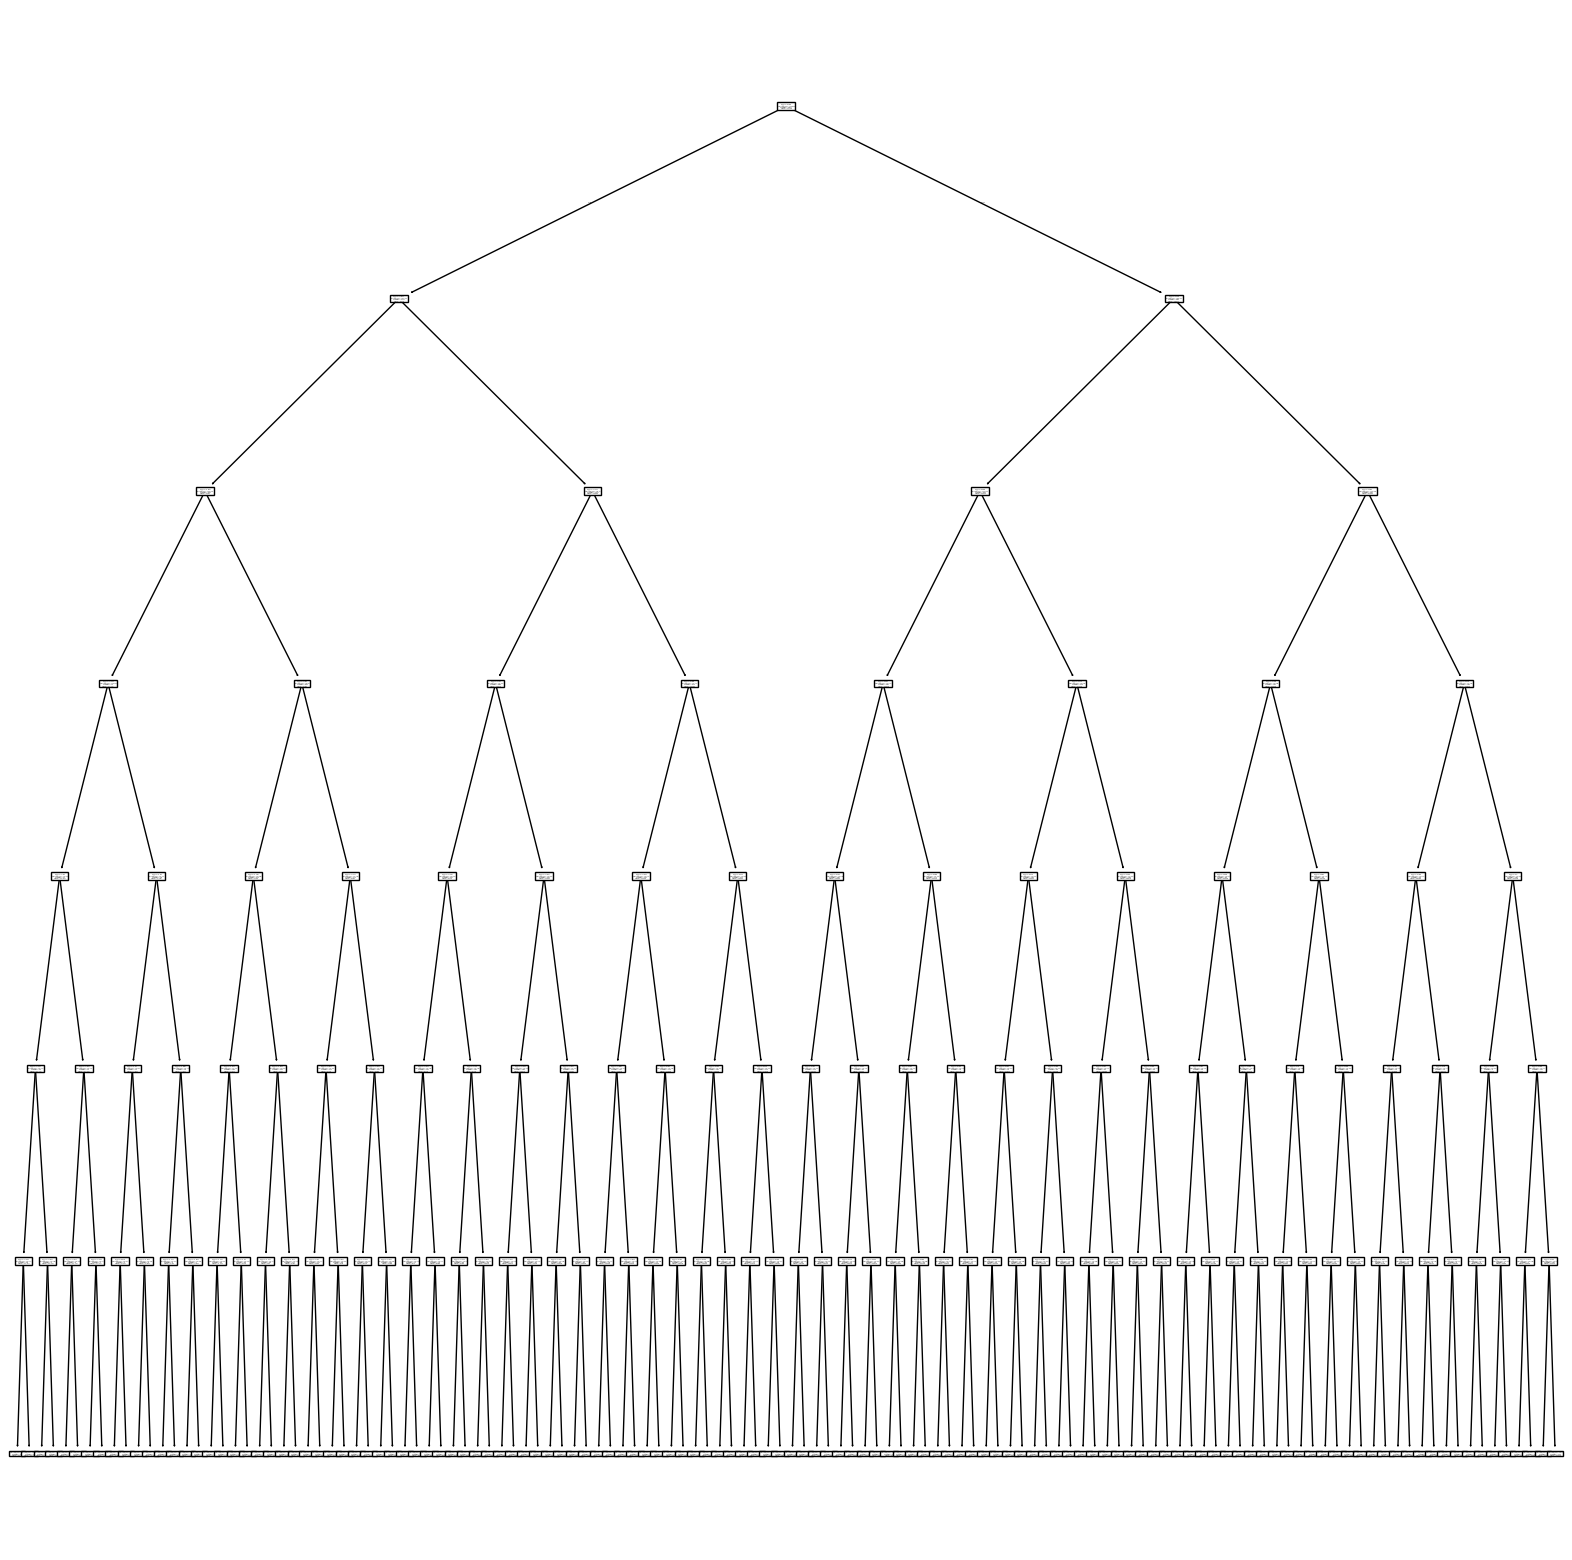

In [93]:
plt.figure(figsize=(20,20))
from sklearn import tree
tree.plot_tree(DT.fit(X_train,y_train))

In [94]:
print(DT.score(X_train,y_train))
print(DT.score(X_test,y_test))

0.9998795034539074
0.9998517033918632


### Random Forest

In [95]:
from sklearn.ensemble import RandomForestRegressor

In [96]:
RFR= RandomForestRegressor(n_estimators=100,criterion='squared_error',random_state=42,max_depth=7)

In [97]:
RFR.fit(X_train,y_train)

RandomForestRegressor(max_depth=7, random_state=42)

In [98]:
y_pred = RFR.predict(X_test)

In [99]:
y_pred[0:10]

array([-4.67132631,  3.55326655, 23.65397455, -1.44419712, 22.38373084,
       11.89027483, 17.84319824, 22.28350387,  6.5003713 , 22.9075884 ])

In [100]:
rf_mse = mean_squared_error(y_test,y_pred)

In [101]:
rf_mse

0.002371305463389244

In [102]:
rf_mae = mean_absolute_error(y_test,y_pred)

In [103]:
rf_mae

0.02997483577936886

In [104]:
rf_rmse = np.sqrt(mean_squared_error(y_test,y_pred))

In [105]:
rf_rmse

np.float64(0.04869605182547394)

In [106]:
rf_r2 = r2_score(y_test,y_pred)

In [107]:
rf_r2

0.9999817581574362

In [108]:
n = len(y_test)
p = X_test.shape[1]

rf_adj_r2 = 1-((1-r2)*(n-1)/(n-p-1))

In [109]:
print(RFR.score(X_train,y_train))
print(RFR.score(X_test,y_test))

0.9999892136032091
0.9999817581574362


### XGBoost

In [110]:
pip install xgboost


Note: you may need to restart the kernel to use updated packages.


In [111]:
from xgboost import XGBRegressor


In [112]:
xgmodel = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgmodel.fit(X_train, y_train)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [113]:
y_pred = model.predict(X_test)


In [114]:
y_pred[0:10]

array([-4.92,  3.55, 23.57, -1.33, 22.39, 11.92, 17.84, 22.22,  6.48,
       22.97])

In [115]:
xgmse = cross_val_score(xgmodel,X_train,y_train,scoring='neg_mean_squared_error',cv=10)

In [116]:
xgmse

array([-0.31346111, -0.23606848, -0.30732464, -0.20396766, -0.4589142 ,
       -0.28684004, -0.29871391, -0.30783751, -0.34138583, -0.3374943 ])

In [117]:
y_pred=xgmodel.predict(X_test)
x_pred=xgmodel.predict(X_train)

In [118]:
y_pred[0:10]

array([-4.207945 ,  3.0052934, 23.744244 , -0.9935963, 22.432482 ,
       12.040396 , 17.777748 , 22.15264  ,  6.4109173, 23.181875 ],
      dtype=float32)

In [119]:
x_pred[0:10]

array([38.567566 , 18.89579  ,  6.231874 , 41.264317 ,  2.9445002,
       12.524353 , 10.502782 ,  8.807503 ,  6.624295 , 16.101778 ],
      dtype=float32)

In [120]:
xgmse = mean_squared_error(y_test,y_pred)

In [121]:
xgmse

0.28210009423979976

In [122]:
xgmae = mean_absolute_error(y_test,y_pred)

In [123]:
xgmae

0.33860459565297035

In [124]:
xgmse = np.sqrt(mean_squared_error(y_test,y_pred))

In [125]:
xgmse

np.float64(0.531130957711749)

In [126]:
xgr2 = r2_score(y_test,y_pred)

In [127]:
xgr2

0.9978298765866249

In [128]:
n = len(y_test)
p = X_test.shape[1]

xgadj_r2 = 1-((1-r2)*(n-1)/(n-p-1))

In [129]:
xgadj_r2

1.0

In [130]:
xgmod_df=pd.DataFrame({'Actual':y_test,'Prediction':y_pred,'Diff %':((y_test - y_pred) / y_test)*100})

In [131]:
xgmod_df

,Actual,Prediction,Diff %
3019,-4.92,-4.207945,14.472665
3433,3.55,3.005293,15.343849
345,23.57,23.744244,-0.739260
1393,-1.33,-0.993596,25.293510
2325,22.39,22.432482,-0.189735
...,...,...,...
197,22.71,22.837044,-0.559418
1175,10.96,10.743006,1.979875
124,34.94,34.696495,0.696923
857,6.09,6.674322,-9.594780


In [132]:
print(xgmodel.score(X_train,y_train))
print(xgmodel.score(X_test,y_test))

0.9998947466909047
0.9978298765866249


In [133]:
ridge = Ridge(alpha = 1.0)
ridge.fit(X_train,y_train)
ridge.coef_

array([-1.74306516e-03,  9.39949320e-04, -1.57512359e-03, -2.72583040e-04,
       -2.70368342e-04,  7.72058927e-04, -9.78224185e-04, -1.42035128e-03,
        4.47530794e-04,  1.13714702e+01])

In [134]:
print(ridge.score(X_train,y_train))
print(ridge.score(X_train,y_train))

0.9999998591491062
0.9999998591491062


In [135]:
lasso = Lasso(alpha = 1.0)
lasso.fit(X_train,y_train)
lasso.coef_

array([-0.        ,  0.        , -0.        ,  0.        ,  0.        ,
        0.        , -0.        ,  0.        ,  0.        , 10.37473479])

In [136]:
print(lasso.score(X_train,y_train))
print(lasso.score(X_train,y_train))

0.9922479680530205
0.9922479680530205


### Pickle Model Saving

In [137]:
import pickle

# Save model
with open("model.pkl", "wb") as file:
    pickle.dump(model, file)

In [138]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
import pickle

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestRegressor())
])

pipeline.fit(X_train, y_train)

with open("pipeline.pkl", "wb") as f:
    pickle.dump(pipeline, f)